<a href="https://colab.research.google.com/github/Diptechdd/Asp.Net/blob/main/CNN_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, transform=transform_train, download=True)

val_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, transform=transform_test, download=True)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64, shuffle=False)


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = CNN().to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=10, gamma=0.5)


num_epochs = 50
best_acc = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total


    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {total_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Acc: {val_acc:.2f}%")


    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print(f"\n✅ Best Validation Accuracy: {best_acc:.2f}%")

100%|██████████| 170M/170M [00:02<00:00, 79.4MB/s]


Epoch [1/50] Loss: 1145.5711 Train Acc: 46.47% Val Acc: 59.90%
Epoch [2/50] Loss: 909.1690 Train Acc: 58.58% Val Acc: 67.00%
Epoch [3/50] Loss: 818.1402 Train Acc: 63.30% Val Acc: 70.72%
Epoch [4/50] Loss: 753.2013 Train Acc: 66.60% Val Acc: 69.80%
Epoch [5/50] Loss: 706.3576 Train Acc: 68.64% Val Acc: 74.12%
Epoch [6/50] Loss: 671.5168 Train Acc: 70.28% Val Acc: 75.44%
Epoch [7/50] Loss: 645.0809 Train Acc: 71.56% Val Acc: 76.20%
Epoch [8/50] Loss: 618.5776 Train Acc: 72.77% Val Acc: 76.14%
Epoch [9/50] Loss: 594.3748 Train Acc: 74.02% Val Acc: 76.04%
Epoch [10/50] Loss: 576.1008 Train Acc: 74.92% Val Acc: 78.05%
Epoch [11/50] Loss: 516.1200 Train Acc: 77.39% Val Acc: 80.25%
Epoch [12/50] Loss: 497.8809 Train Acc: 78.15% Val Acc: 80.97%
Epoch [13/50] Loss: 480.9845 Train Acc: 79.05% Val Acc: 80.97%
Epoch [14/50] Loss: 474.0112 Train Acc: 79.50% Val Acc: 81.40%
Epoch [15/50] Loss: 461.1454 Train Acc: 79.90% Val Acc: 80.75%
Epoch [16/50] Loss: 447.6228 Train Acc: 80.57% Val Acc: 81.04%


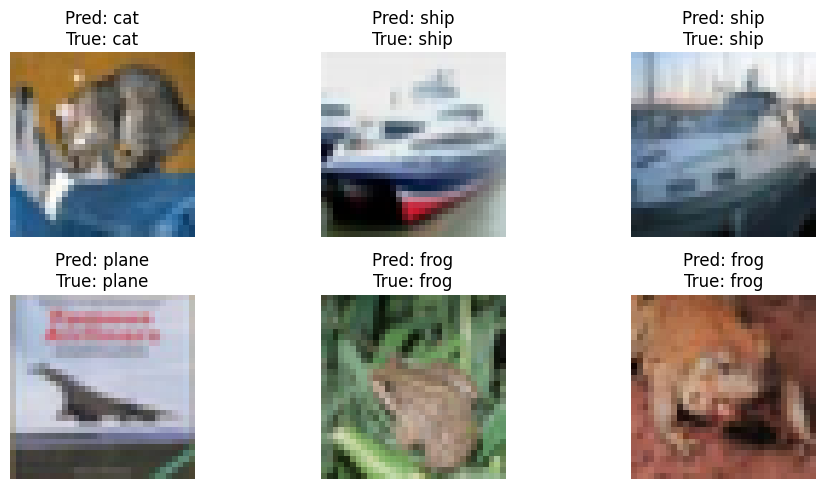

In [2]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')


dataiter = iter(val_loader)
images, labels = next(dataiter)


images = images.to(device)
labels = labels.to(device)


model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    imshow(images[i])
    plt.title(f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}")
plt.tight_layout()
plt.show()

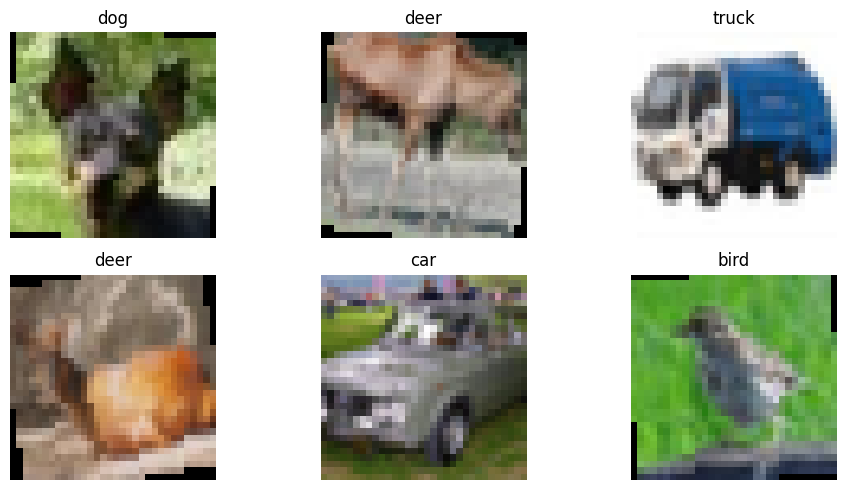

In [4]:
import matplotlib.pyplot as plt
import numpy as np


classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')


def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')


dataiter = iter(train_loader)
images, labels = next(dataiter)


plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    imshow(images[i])
    plt.title(classes[labels[i]])
plt.tight_layout()
plt.show()